C:\Users\horie\machine_learning\lab2\data\car.png -> Predicted class: crash_helmet


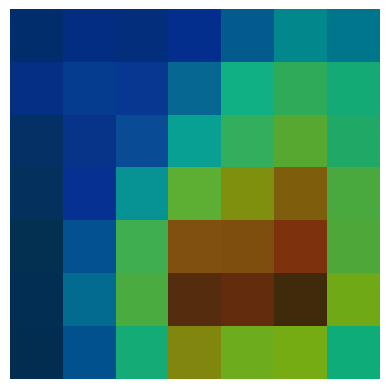

C:\Users\horie\machine_learning\lab2\data\dog.png -> Predicted class: Pembroke


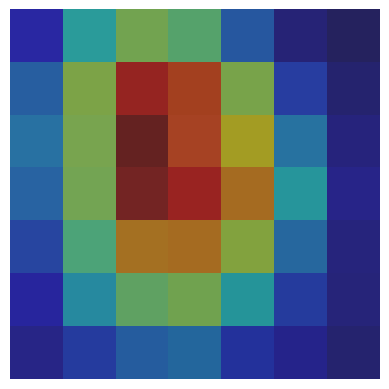

C:\Users\horie\machine_learning\lab2\data\Screenshot 2026-04-22 160121.png -> Predicted class: goldfish


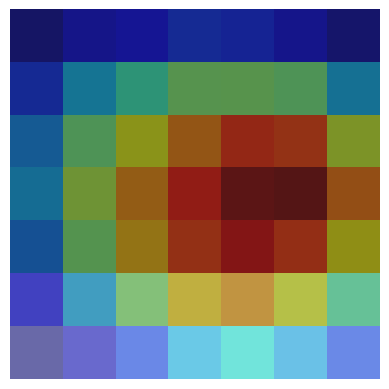

In [10]:
%matplotlib inline
from zipfile import Path

import torch
import torchvision.models as models
from PIL import Image
from torchvision import transforms
import json
import matplotlib.pyplot as plt
from torchcam.methods import SmoothGradCAMpp
import glob



#explor Dataset
# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()

# Preprocessing
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load ImageNet class index
json_path = r"C:\Users\horie\machine_learning\lab2\imagenet_class_index (2).json"
with open(json_path, "r") as f:
    idx_to_class = json.load(f)

# Attach CAM extractor
cam_extractor = SmoothGradCAMpp(model)

# Loop through all PNG images
img_paths = glob.glob(r"C:\Users\horie\machine_learning\lab2\data\*.png")

for img_path in img_paths:
    img = Image.open(img_path).convert("RGB")
    input_tensor = preprocess(img).unsqueeze(0)
    input_tensor.requires_grad_()   # <-- important fix

    # Prediction
    outputs = model(input_tensor)
    _, predicted_idx = outputs.max(1)

    predicted_class = idx_to_class[str(predicted_idx.item())][1]
    print(f"{img_path} -> Predicted class: {predicted_class}")

    # CAM visualization
    activation_map = cam_extractor(predicted_idx.item(), outputs)

    fig, ax = plt.subplots()
    ax.imshow(img)
    ax.imshow(activation_map[0].squeeze(0), cmap="jet", alpha=0.5)
    ax.axis("off")
    plt.show()






In [11]:
import json

# Load JSON file
json_path = r"C:\Users\horie\machine_learning\lab2\imagenet_class_index (2).json"
with open(json_path, "r") as f:
    idx_to_class = json.load(f)

# Show total number of classes
print("Number of classes:", len(idx_to_class))

# Print first 20 classes to explore
for i in range(20):
    print(i, "->", idx_to_class[str(i)])


Number of classes: 1000
0 -> ['n01440764', 'tench']
1 -> ['n01443537', 'goldfish']
2 -> ['n01484850', 'great_white_shark']
3 -> ['n01491361', 'tiger_shark']
4 -> ['n01494475', 'hammerhead']
5 -> ['n01496331', 'electric_ray']
6 -> ['n01498041', 'stingray']
7 -> ['n01514668', 'cock']
8 -> ['n01514859', 'hen']
9 -> ['n01518878', 'ostrich']
10 -> ['n01530575', 'brambling']
11 -> ['n01531178', 'goldfinch']
12 -> ['n01532829', 'house_finch']
13 -> ['n01534433', 'junco']
14 -> ['n01537544', 'indigo_bunting']
15 -> ['n01558993', 'robin']
16 -> ['n01560419', 'bulbul']
17 -> ['n01580077', 'jay']
18 -> ['n01582220', 'magpie']
19 -> ['n01592084', 'chickadee']



Processing class: goldfish
Found images: [WindowsPath('C:/Users/horie/machine_learning/lab2/data/goldFish/goldFish.png'), WindowsPath('C:/Users/horie/machine_learning/lab2/data/goldFish/salmonFish.png')]
C:\Users\horie\machine_learning\lab2\data\goldFish\goldFish.png -> Predicted class: goldfish


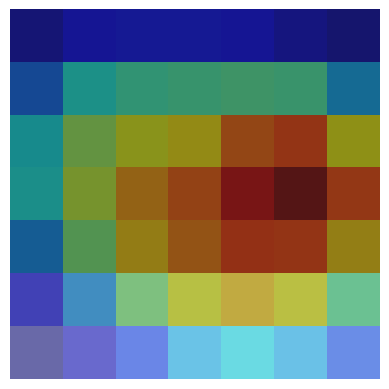

Saved CAM overlay to lab2\results\goldfish_goldFish_cam.png
C:\Users\horie\machine_learning\lab2\data\goldFish\salmonFish.png -> Predicted class: puffer


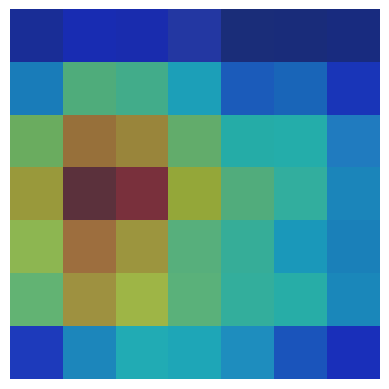

Saved CAM overlay to lab2\results\goldfish_salmonFish_cam.png

Processing class: labrador
Found images: [WindowsPath('C:/Users/horie/machine_learning/lab2/data/labrador/dog.png'), WindowsPath('C:/Users/horie/machine_learning/lab2/data/labrador/germanshepered.png')]
C:\Users\horie\machine_learning\lab2\data\labrador\dog.png -> Predicted class: Pembroke


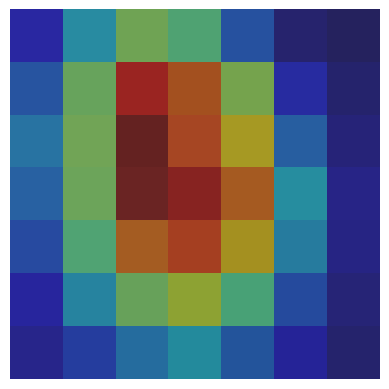

Saved CAM overlay to lab2\results\labrador_dog_cam.png
C:\Users\horie\machine_learning\lab2\data\labrador\germanshepered.png -> Predicted class: German_shepherd


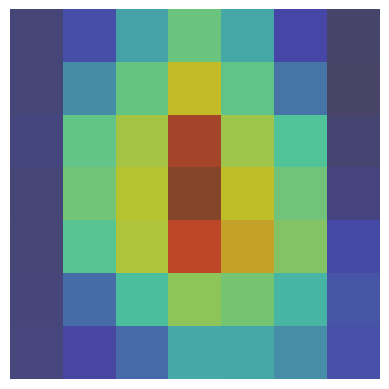

Saved CAM overlay to lab2\results\labrador_germanshepered_cam.png

Processing class: ambulance
Found images: [WindowsPath('C:/Users/horie/machine_learning/lab2/data/ambulance/ambulance.png'), WindowsPath('C:/Users/horie/machine_learning/lab2/data/ambulance/car.png')]
C:\Users\horie\machine_learning\lab2\data\ambulance\ambulance.png -> Predicted class: ambulance


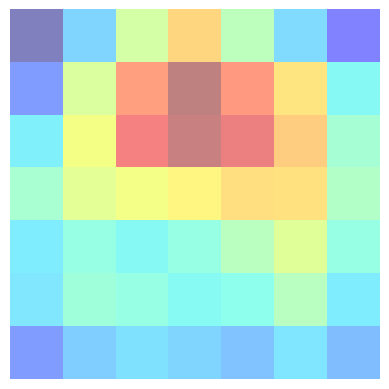

Saved CAM overlay to lab2\results\ambulance_ambulance_cam.png
C:\Users\horie\machine_learning\lab2\data\ambulance\car.png -> Predicted class: crash_helmet


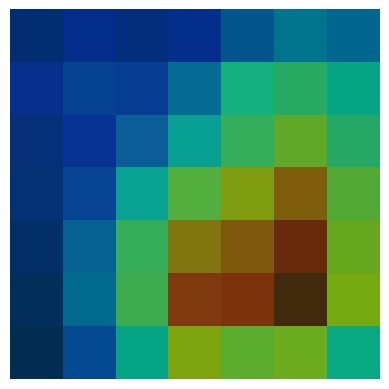

Saved CAM overlay to lab2\results\ambulance_car_cam.png


In [17]:
%matplotlib inline
from torchvision import transforms
import torch
import torchvision.models as models
from PIL import Image
import json
import matplotlib.pyplot as plt
from torchcam.methods import SmoothGradCAMpp
import glob
from pathlib import Path

# Preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize all images to 224x224
    transforms.ToTensor(),           # Convert image to PyTorch tensor
    transforms.Normalize(            # Normalize with ImageNet mean/std
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])


# Load model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()

# Load JSON class index
json_path = r"C:\Users\horie\machine_learning\lab2\imagenet_class_index (2).json"
with open(json_path, "r") as f:
    idx_to_class = json.load(f)

# Attach CAM extractor
cam_extractor = SmoothGradCAMpp(model)

# Paths
base_dir = Path(r"C:\Users\horie\machine_learning\lab2\data")

results_dir = Path("lab2/results")
results_dir.mkdir(parents=True, exist_ok=True)

classes = ["goldfish", "labrador", "ambulance"]

for cls in classes:
    print(f"\nProcessing class: {cls}")
    img_paths = list(base_dir.glob(f"{cls}/*.png"))
    print("Found images:", img_paths)

    for img_path in img_paths:
        img = Image.open(img_path).convert("RGB")
        input_tensor = preprocess(img).unsqueeze(0)
        input_tensor.requires_grad_()

        # Prediction
        outputs = model(input_tensor)
        _, predicted_idx = outputs.max(1)
        predicted_class = idx_to_class[str(predicted_idx.item())][1]
        print(f"{img_path} -> Predicted class: {predicted_class}")

        # CAM visualization
        activation_map = cam_extractor(predicted_idx.item(), outputs)

        fig, ax = plt.subplots()
        ax.imshow(img)
        ax.imshow(activation_map[0].squeeze(0), cmap="jet", alpha=0.5)
        ax.axis("off")

        # Save into results folder
        filename = f"{cls}_{img_path.stem}_cam.png"
        save_path = results_dir / filename
        plt.savefig(save_path, bbox_inches="tight")

        # Show inline in notebook
        plt.show()
       

        print(f"Saved CAM overlay to {save_path}")
